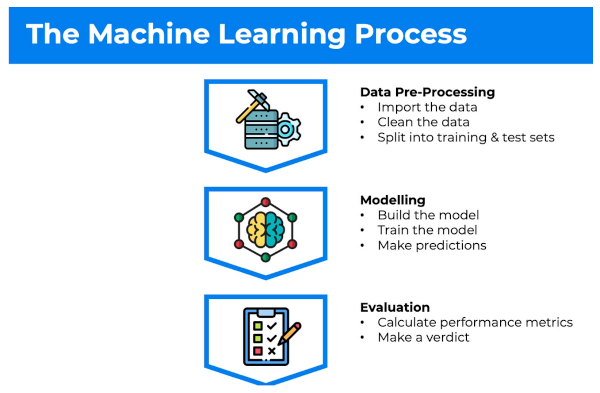

# Data Preprocessing Tools

## Downloading the data

In [ ]:
!wget -O Data.csv 'https://drive.google.com/uc?export=download&id=1Q-Q6TZgQWCQoXfNbhQvEy1aTS3Bry61r'

--2025-09-30 05:16:50--  https://drive.google.com/uc?export=download&id=1Q-Q6TZgQWCQoXfNbhQvEy1aTS3Bry61r
Resolving drive.google.com (drive.google.com)... 142.251.170.102, 142.251.170.139, 142.251.170.100, ...
Connecting to drive.google.com (drive.google.com)|142.251.170.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Q-Q6TZgQWCQoXfNbhQvEy1aTS3Bry61r&export=download [following]
--2025-09-30 05:16:51--  https://drive.usercontent.google.com/download?id=1Q-Q6TZgQWCQoXfNbhQvEy1aTS3Bry61r&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.188.132, 2404:6800:4008:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.188.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 249 [application/octet-stream]
Saving to: ‘Data.csv’

Data.csv            100%[===================>]     249  --.-KB/s    in 0s    

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [ ]:
dataset = pd.read_csv('Data.csv')
X = dataset.iloc[:].values
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,-38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,42.0,283000.0,Yes
9,France,37.0,67000.0,Yes


## Outlier values / data quality


*   Outliers as measurement **errors**, **typos**, or **noise** - leads to worse performance of a model

*   Outliers are real but rare cases, removing them may hurt generalization — the model won’t learn how to classify those edge cases.



In [ ]:
dataset.describe()

,Age,Salary
count,10.000000,10.000000
mean,26.500000,83600.000000
std,26.349151,70684.274536
min,-38.000000,48000.000000
25%,27.750000,55000.000000
50%,36.000000,61500.000000
75%,41.500000,70750.000000
max,48.000000,283000.000000


### Common approaches to handling outliers

-   **Detect & remove obvious errors:**  
    e.g., negative ages, impossible values, or clear data entry mistakes.
    
-   **Winsorization / capping:**  
    Replace values above the 99th percentile (or some chosen threshold) with that percentile value. Same for the lower tail.
        
-   **Robust scaling:**  
    Instead of standard scaling (mean, std), use **median and IQR**. Example: `RobustScaler` in scikit-learn.
    
-   **Separate treatment:**  
    Flag extreme values with a new feature (binary "is\_outlier" column), and let the model learn that rare condition.

In [ ]:
# Assuming 'Age' is the second column (index 1) in the original X array
# Filter out rows where Age is negative, ignoring NaN values
# Convert the Age column to float before filtering
X_age = X[:, 1].astype(float)
X = X[(X_age >= 0) | (np.isnan(X_age))]
X

array([['France', 44.0, 72000.0, 'No'],
       ['Spain', 27.0, 48000.0, 'Yes'],
       ['Germany', 30.0, 54000.0, 'No'],
       ['Germany', 40.0, nan, 'Yes'],
       ['France', 35.0, 58000.0, 'Yes'],
       ['Spain', nan, 52000.0, 'No'],
       ['France', 48.0, 79000.0, 'Yes'],
       ['Germany', 42.0, 283000.0, 'Yes'],
       ['France', 37.0, 67000.0, 'Yes'],
       ['Germany', 0.0, 62000.0, 'No']], dtype=object)

## Taking care of missing data

In [ ]:
! pip -q install scikit-learn

In [ ]:
# Assuming 'Age' is at index 1 in the X array
# Replace all zeros with np.nan
X[X[:, 1] == 0, 1] = np.nan
X

array([['France', 44.0, 72000.0, 'No'],
       ['Spain', 27.0, 48000.0, 'Yes'],
       ['Germany', 30.0, 54000.0, 'No'],
       ['Germany', 40.0, nan, 'Yes'],
       ['France', 35.0, 58000.0, 'Yes'],
       ['Spain', nan, 52000.0, 'No'],
       ['France', 48.0, 79000.0, 'Yes'],
       ['Germany', 42.0, 283000.0, 'Yes'],
       ['France', 37.0, 67000.0, 'Yes'],
       ['Germany', nan, 62000.0, 'No']], dtype=object)

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

## Option 1
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

# ## Option 2
X[:, 1:3] = imputer.fit_transform(X[:, 1:3])

print(X)

[['France' 44.0 72000.0 'No']
 ['Spain' 27.0 48000.0 'Yes']
 ['Germany' 30.0 54000.0 'No']
 ['Germany' 40.0 62000.0 'Yes']
 ['France' 35.0 58000.0 'Yes']
 ['Spain' 38.5 52000.0 'No']
 ['France' 48.0 79000.0 'Yes']
 ['Germany' 42.0 283000.0 'Yes']
 ['France' 37.0 67000.0 'Yes']
 ['Germany' 38.5 62000.0 'No']]


### Flag outlier values with a new feature (column)

In [ ]:
# Find 99th percentile of Salary column
salary_99th_percentile = np.percentile(X[:,2], 99)
print(f"The 99th percentile of the Salary column is: {salary_99th_percentile}")

The 99th percentile of the Salary column is: 264640.0


In [ ]:
# Add a new column to X, initialized with zeros
X = np.append(X, np.zeros((X.shape[0], 1)), axis=1)
print(X)

[['France' 44.0 72000.0 'No' 0.0]
 ['Spain' 27.0 48000.0 'Yes' 0.0]
 ['Germany' 30.0 54000.0 'No' 0.0]
 ['Germany' 40.0 62000.0 'Yes' 0.0]
 ['France' 35.0 58000.0 'Yes' 0.0]
 ['Spain' 38.5 52000.0 'No' 0.0]
 ['France' 48.0 79000.0 'Yes' 0.0]
 ['Germany' 42.0 283000.0 'Yes' 0.0]
 ['France' 37.0 67000.0 'Yes' 0.0]
 ['Germany' 38.5 62000.0 'No' 0.0]]


In [ ]:
# Assuming Salary is at index 2 and the new column is at index 4
# Set the last column to 1 where salary is greater than its 99 percentile
X[X[:, 2] > np.percentile(X[:,2], 99), 4] = 1
X

array([['France', 44.0, 72000.0, 'No', 0.0],
       ['Spain', 27.0, 48000.0, 'Yes', 0.0],
       ['Germany', 30.0, 54000.0, 'No', 0.0],
       ['Germany', 40.0, 62000.0, 'Yes', 0.0],
       ['France', 35.0, 58000.0, 'Yes', 0.0],
       ['Spain', 38.5, 52000.0, 'No', 0.0],
       ['France', 48.0, 79000.0, 'Yes', 0.0],
       ['Germany', 42.0, 283000.0, 'Yes', 1],
       ['France', 37.0, 67000.0, 'Yes', 0.0],
       ['Germany', 38.5, 62000.0, 'No', 0.0]], dtype=object)

## Dependent / independent variable

In [ ]:
# Independent variables are the ones which through we are trying to
# explain the value or effect of the output variable (dependent variable)
# by creating a relationship between an independent and dependent variable.

# Extract y variable (purchased column), which is now at index 5
y = X[:, -2]

# # Remove y column from X array
X = np.delete(X, -2, axis=1)

In [ ]:
# Dependent variables are nothing but the variable which holds the phenomena which we are studying.

print(y)   # dependent variable

['No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No']


In [ ]:
print(X)

[['France' 44.0 72000.0 0.0]
 ['Spain' 27.0 48000.0 0.0]
 ['Germany' 30.0 54000.0 0.0]
 ['Germany' 40.0 62000.0 0.0]
 ['France' 35.0 58000.0 0.0]
 ['Spain' 38.5 52000.0 0.0]
 ['France' 48.0 79000.0 0.0]
 ['Germany' 42.0 283000.0 1]
 ['France' 37.0 67000.0 0.0]
 ['Germany' 38.5 62000.0 0.0]]


## Encoding categorical data

### Encoding the Independent Variable

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough') # transformer = [(kind of tranformation, kind of encoding, index of column to encode)]
                                                                                                  # remainder = remain other column untouched

X = np.array(ct.fit_transform(X))
X

array([[1.0, 0.0, 0.0, 44.0, 72000.0, 0.0],
       [0.0, 0.0, 1.0, 27.0, 48000.0, 0.0],
       [0.0, 1.0, 0.0, 30.0, 54000.0, 0.0],
       [0.0, 1.0, 0.0, 40.0, 62000.0, 0.0],
       [1.0, 0.0, 0.0, 35.0, 58000.0, 0.0],
       [0.0, 0.0, 1.0, 38.5, 52000.0, 0.0],
       [1.0, 0.0, 0.0, 48.0, 79000.0, 0.0],
       [0.0, 1.0, 0.0, 42.0, 283000.0, 1],
       [1.0, 0.0, 0.0, 37.0, 67000.0, 0.0],
       [0.0, 1.0, 0.0, 38.5, 62000.0, 0.0]], dtype=object)

In [ ]:
ct.transform([['France', 37, 58000, 0]])

In [ ]:
ct.__dict__

### Encoding the Dependent Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 1, 0, 1, 1, 0, 1, 1, 1, 0])

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 55)

In [ ]:
print(X_train)

[[0.0 1.0 0.0 30.0 54000.0 0.0]
 [0.0 0.0 1.0 27.0 48000.0 0.0]
 [0.0 1.0 0.0 40.0 62000.0 0.0]
 [1.0 0.0 0.0 48.0 79000.0 0.0]
 [0.0 1.0 0.0 38.5 62000.0 0.0]
 [0.0 0.0 1.0 38.5 52000.0 0.0]
 [1.0 0.0 0.0 37.0 67000.0 0.0]
 [0.0 1.0 0.0 42.0 283000.0 1]]


In [ ]:
print(X_test)

[[1.0 0.0 0.0 35.0 58000.0 0.0]
 [1.0 0.0 0.0 44.0 72000.0 0.0]]


In [ ]:
print(y_train)

[0 1 1 1 0 0 1 1]


In [ ]:
print(y_test)

[1 0]


## Feature Scaling
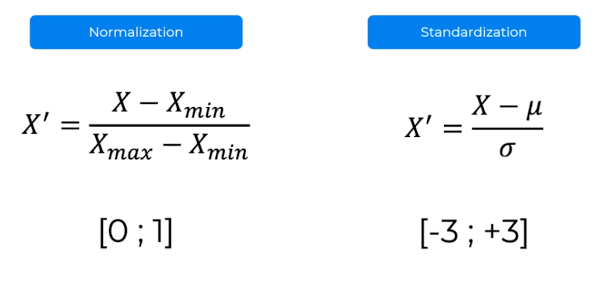

Which persons are most similar based on data? Blue to purple? Red to blue? ...
Take a look on differencies between their salaries and age. How much different values are? Does it even make sense?

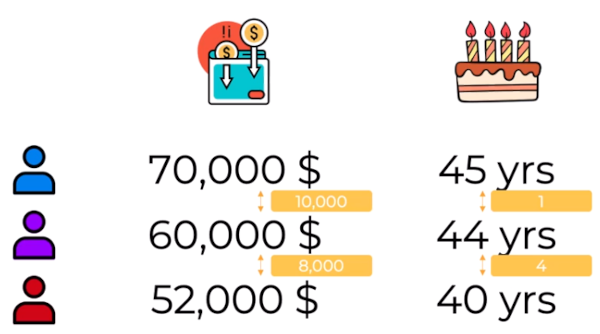

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 3:] = sc.fit_transform(X_train[:, 3:])
X_test[:, 3:] = sc.transform(X_test[:, 3:])           # notice, that tranform method is used instead fit_transform

In [ ]:
print(X_train)

[[0.0 1.0 0.0 -1.2341504375467889 -0.4637766489550594 -0.3779644730092272]
 [0.0 0.0 1.0 -1.7197178228110992 -0.544726754954488 -0.3779644730092272]
 [0.0 1.0 0.0 0.3844075133342457 -0.3558431742891547 -0.3779644730092272]
 [1.0 0.0 0.0 1.6792538740390732 -0.1264845406241071 -0.3779644730092272]
 [0.0 1.0 0.0 0.14162382070209056 -0.3558431742891547 -0.3779644730092272]
 [0.0 0.0 1.0 0.14162382070209056 -0.4907600176215356 -0.3779644730092272]
 [1.0 0.0 0.0 -0.10115987193006465 -0.2883847526229642
  -0.3779644730092272]
 [0.0 1.0 0.0 0.7081191035104526 2.6258190633564635 2.6457513110645907]]


In [ ]:
print(X_test)

[[1.0 0.0 0.0 -0.4248714621062715 -0.409809911622107 -0.3779644730092272]
 [1.0 0.0 0.0 1.0318306936866593 -0.22092633095677375 -0.3779644730092272]]


# Task for you

### **Learning objective**
Apply standardization on the Wine Quality Red dataset using Python, Pandas, and Scikit-learn.

### **What to do**
Load data about wines and apply following steps:

1. Download data: https://mta.pef.mendelu.cz/~xvalovic/vyuka/nsa/wines_data.csv

2. Import the necessary libraries for data preprocessing, including the StandardScaler and train_test_split classes.

3. Load the "Wine Quality Red" dataset into a pandas DataFrame. You can use the pd.read_csv function for this. Make sure you set the correct delimeter for the file.

4. Split your dataset into an 80-20 training-test set. Set random_state to 42 (or any other integer) to ensure reproducible results.

5. Create an instance of the StandardScaler class.

6. Fit the StandardScaler on features from the training set, excluding the target variable 'Quality'.

7. Use the "fit_transform" method of the StandardScaler object on the training dataset.

8. Apply the "transform" method of the StandardScaler object on the test dataset.

9. Print your scaled training and test datasets to verify the feature scaling process.


Did we miss something?